# SMS Spam Filtering Project
My goal here is to classify text messages as Spam or Ham.
I will test four models: Naive Bayes, Decision Tree, SVM, and an MLP Neural Network.

In [1]:
# Importing all the required libraries for the project
import os, warnings, re
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
STOP_WORDS = set(stopwords.words('english'))

print("Libraries loaded.")

Libraries loaded.


## 1. Load Data
Loading the csv file and dropping the extra empty columns.

In [2]:
df = pd.read_csv('spam.csv', encoding='latin-1') #latin-1 bcs unicpde error

# Keeping the two columns that have data
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

print("Original Data Count:")
print(df['label'].value_counts())

Original Data Count:
label
ham     4825
spam     747
Name: count, dtype: int64


## 2. Text Cleaning and TF-IDF
Converting everything to lowercase, removing symbols and applying TF-IDF.
(will apply SMOTE later inside the train loops to prevent data leakage)

In [3]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [w for w in tokens if w not in STOP_WORDS]
    return ' '.join(tokens)

df['cleaned'] = df['message'].apply(clean_text)

# Convert labels to 0 and 1
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])

# Vectorize the text
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['cleaned'])
y = df['label_enc'].values

print("Text cleaning and vectorization done.")

print("Cleaning verification (before vs after):")
display(df[['message', 'cleaned']].head(5))

Text cleaning and vectorization done.
Cleaning verification (before vs after):


,message,cleaned
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


## 3. Helper Functions & Settings
defining required settings(splits, seeds and learning rates)

In [4]:
def get_metrics(y_true, y_pred):
    return {
        'accuracy' : accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall'   : recall_score(y_true, y_pred, zero_division=0),
        'f1'       : f1_score(y_true, y_pred, zero_division=0),
    }

def build_mlp(input_dim, learning_rate=0.001):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Global Settings
SPLITS = [(0.2, '80-20'), (0.3, '70-30'), (0.4, '60-40')]
SEEDS = [0, 42, 100]

# List to hold all the results
all_results = []

print("Settings applyed")

Settings applyed


## 4. Naive Bayes Experiments

In [5]:
NB_ALPHAS = [0.1, 0.5, 1.0]

for seed in SEEDS:
    for test_size, split_name in SPLITS:
        X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=test_size, random_state=seed)# Splitted first to stop data leak

        smote = SMOTE(random_state=seed)# Applied SMOTE only to training set
        X_tr_bal, y_tr_bal = smote.fit_resample(X_tr, y_tr)

        for alpha in NB_ALPHAS:
            nb = MultinomialNB(alpha=alpha)
            nb.fit(X_tr_bal, y_tr_bal)
            pred = nb.predict(X_te)
            m = get_metrics(y_te, pred)
            all_results.append({'Model': 'Naive Bayes', 'Parameter / LR': f'Alpha={alpha}', 'Split': split_name, 'Seed': seed, **m})

print("Naive Bayes loops finished.")

Naive Bayes loops finished.


## 5. Decision Tree Experiments

In [6]:
DT_DEPTHS = [5, 10, 15]

for seed in SEEDS:
    for test_size, split_name in SPLITS:
        X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=test_size, random_state=seed)

        smote = SMOTE(random_state=seed)
        X_tr_bal, y_tr_bal = smote.fit_resample(X_tr, y_tr)

        for depth in DT_DEPTHS:
            dt = DecisionTreeClassifier(max_depth=depth, random_state=seed)
            dt.fit(X_tr_bal, y_tr_bal)
            pred = dt.predict(X_te)
            m = get_metrics(y_te, pred)
            all_results.append({'Model': 'Decision Tree', 'Parameter / LR': f'Depth={depth}', 'Split': split_name, 'Seed': seed, **m})

print("Decision Tree loops finished.")

Decision Tree loops finished.


## 6. SVM Experiments

In [7]:
SVM_CS = [0.1, 1.0, 10.0]

for seed in SEEDS:
    for test_size, split_name in SPLITS:
        X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=test_size, random_state=seed)

        smote = SMOTE(random_state=seed)
        X_tr_bal, y_tr_bal = smote.fit_resample(X_tr, y_tr)

        for c_val in SVM_CS:
            svm = SVC(C=c_val, kernel='linear', probability=True, max_iter=1000, random_state=seed)
            svm.fit(X_tr_bal, y_tr_bal)
            pred = svm.predict(X_te)
            m = get_metrics(y_te, pred)
            all_results.append({'Model': 'SVM', 'Parameter / LR': f'C={c_val}', 'Split': split_name, 'Seed': seed, **m})

print("SVM loops finished.")

SVM loops finished.


## 7. MLP Neural Network Experiments

In [8]:
MLP_LRS = [0.01, 0.001, 0.0003]
from scipy.sparse import issparse

for seed in SEEDS:
    for test_size, split_name in SPLITS:
        X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=test_size, random_state=seed)

        smote = SMOTE(random_state=seed)
        X_tr_bal, y_tr_bal = smote.fit_resample(X_tr, y_tr)

        # Convert sparse matrix to dense array for neural network
        X_tr_d = X_tr_bal.toarray() if issparse(X_tr_bal) else X_tr_bal
        X_te_d = X_te.toarray() if issparse(X_te) else X_te

        for lr in MLP_LRS:
            tf.keras.backend.clear_session()
            mlp = build_mlp(X_tr_d.shape[1], learning_rate=lr)
            mlp.fit(X_tr_d, y_tr_bal, validation_split=0.1, epochs=15, batch_size=64, verbose=0)

            prob = mlp.predict(X_te_d, verbose=0).flatten()
            pred = (prob >= 0.5).astype(int)
            m = get_metrics(y_te, pred)
            all_results.append({'Model': 'MLP', 'Parameter / LR': f'LR={lr}', 'Split': split_name, 'Seed': seed, **m})

print("MLP loops finished.")

MLP loops finished.


## 8. Final Results Table

In [9]:
results_df = pd.DataFrame(all_results)

# Rounding numbers for clean look
cols_to_round = ['accuracy', 'precision', 'recall', 'f1']
results_df[cols_to_round] = results_df[cols_to_round].round(4)

results_df.rename(columns={
    'accuracy': 'Accuracy',
    'precision': 'Precision',
    'recall': 'Recall',
    'f1': 'F1-Score'
}, inplace=True)

# Sort by accuracy so the best runs are at top
results_df = results_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

display(results_df)

,Model,Parameter / LR,Split,Seed,Accuracy,Precision,Recall,F1-Score
0,MLP,LR=0.01,80-20,42,0.9857,0.9718,0.9200,0.9452
1,MLP,LR=0.01,70-30,42,0.9827,0.9798,0.8858,0.9305
2,MLP,LR=0.001,70-30,42,0.9815,0.9796,0.8767,0.9253
3,MLP,LR=0.01,60-40,42,0.9798,0.9601,0.8863,0.9217
4,MLP,LR=0.0003,70-30,42,0.9797,0.9744,0.8676,0.9179
...,...,...,...,...,...,...,...,...
103,Decision Tree,Depth=5,70-30,0,0.9193,0.7004,0.7563,0.7273
104,Decision Tree,Depth=5,80-20,100,0.9175,0.6568,0.7655,0.7070
105,SVM,C=10.0,60-40,100,0.9166,0.6205,0.9349,0.7459
106,SVM,C=10.0,80-20,100,0.9094,0.5982,0.9241,0.7263


## 9. Visualizations
Generating the plots for the best model settings (80-20 split, Seed 42).

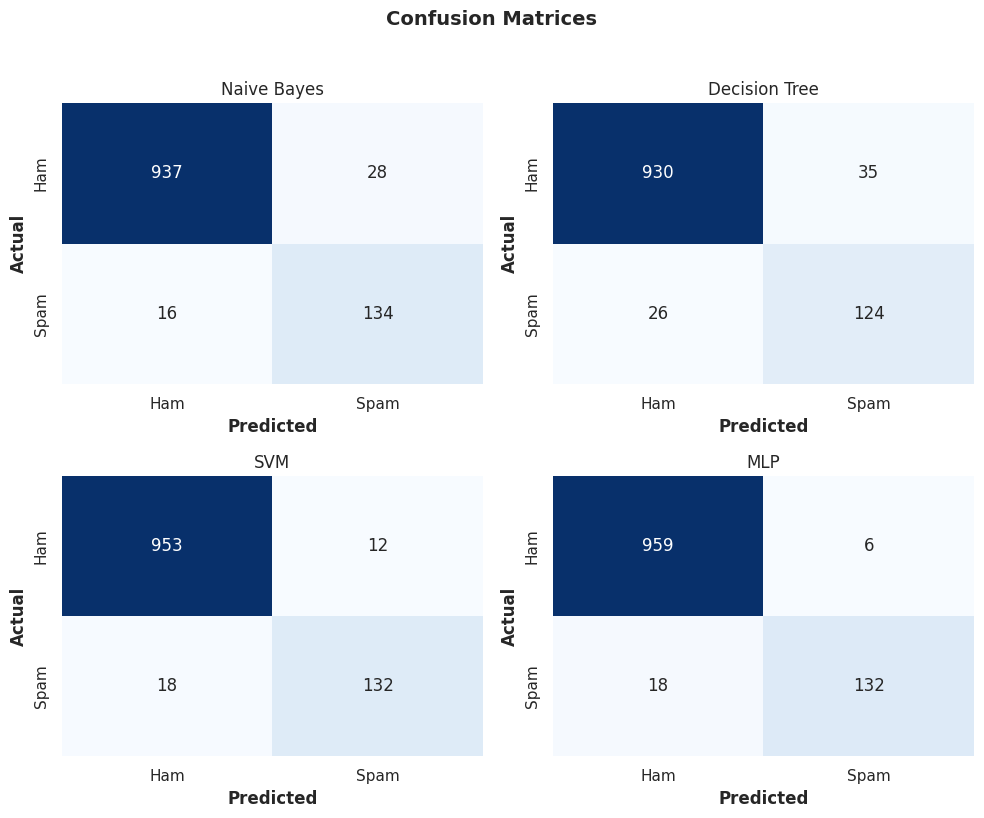

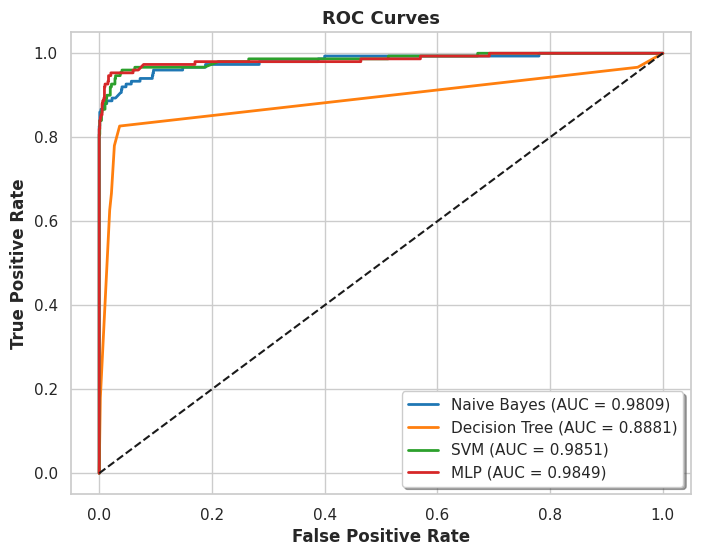

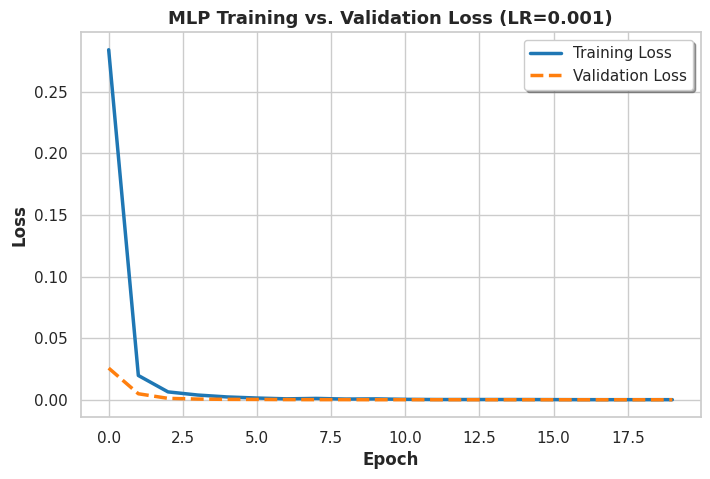

In [10]:
# Setup data for plotting
X_tr80, X_te80, y_tr80, y_te80 = train_test_split(X, y, test_size=0.2, random_state=42)

# SMOTE on train data only
smote_plot = SMOTE(random_state=42)
X_tr80_bal, y_tr80_bal = smote_plot.fit_resample(X_tr80, y_tr80)

X_tr_d = X_tr80_bal.toarray()
X_te_d = X_te80.toarray()

# Train best models quickly for the graphs
nb_best = MultinomialNB(alpha=0.5).fit(X_tr80_bal, y_tr80_bal)
dt_best = DecisionTreeClassifier(max_depth=10, random_state=42).fit(X_tr80_bal, y_tr80_bal)
svm_best = SVC(C=1.0, kernel='linear', probability=True, max_iter=1000, random_state=42).fit(X_tr80_bal, y_tr80_bal)

tf.keras.backend.clear_session()
mlp_best = build_mlp(X_tr_d.shape[1], learning_rate=0.001)
mlp_history = mlp_best.fit(X_tr_d, y_tr80_bal, validation_split=0.1, epochs=20, batch_size=64, verbose=0)

sns.set_theme(style="whitegrid")

# 1. CONFUSION MATRICES
preds = {
    'Naive Bayes': nb_best.predict(X_te80),
    'Decision Tree': dt_best.predict(X_te80),
    'SVM': svm_best.predict(X_te80),
    'MLP': (mlp_best.predict(X_te_d, verbose=0).flatten() >= 0.5).astype(int)
}

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)

for ax, (name, pred) in zip(axes.flatten(), preds.items()):
    sns.heatmap(confusion_matrix(y_te80, pred), annot=True, fmt='d', cmap='Blues',
                cbar=False, ax=ax, xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    ax.set_title(f'{name}', fontsize=12)
    ax.set_ylabel('Actual', fontweight='bold')
    ax.set_xlabel('Predicted', fontweight='bold')

plt.tight_layout()
plt.show()

# 2. ROC CURVES
fig, ax = plt.subplots(figsize=(8, 6))
probs = {
    'Naive Bayes' : nb_best.predict_proba(X_te80)[:, 1],
    'Decision Tree': dt_best.predict_proba(X_te80)[:, 1],
    'SVM'          : svm_best.predict_proba(X_te80)[:, 1],
    'MLP'          : mlp_best.predict(X_te_d, verbose=0).flatten()
}

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for (name, prob), color in zip(probs.items(), colors):
    fpr, tpr, _ = roc_curve(y_te80, prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.4f})', color=color, lw=2)

ax.plot([0, 1], [0, 1], 'k--', lw=1.5)
ax.set_title('ROC Curves', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontweight='bold')
ax.set_ylabel('True Positive Rate', fontweight='bold')
ax.legend(loc='lower right', frameon=True, shadow=True)
plt.show()

# 3. MLP LOSS CURVE
plt.figure(figsize=(8, 5))
plt.plot(mlp_history.history['loss'], label='Training Loss', lw=2.5, color='#1f77b4')
plt.plot(mlp_history.history['val_loss'], label='Validation Loss', lw=2.5, linestyle='--', color='#ff7f0e')
plt.title('MLP Training vs. Validation Loss (LR=0.001)', fontsize=13, fontweight='bold')
plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Loss', fontweight='bold')
plt.legend(frameon=True, shadow=True)
plt.show()

## 10. Comparison Graphs

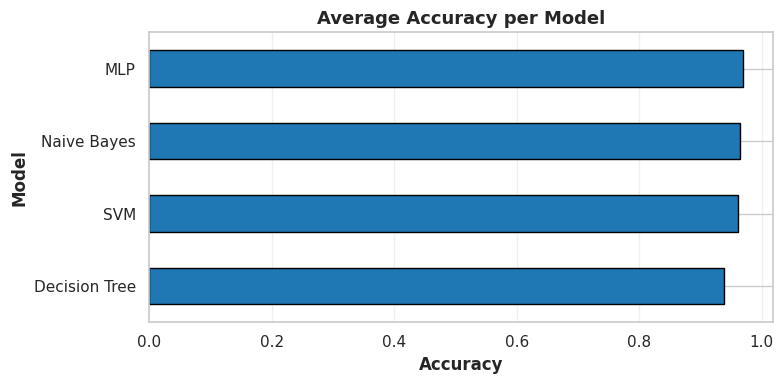

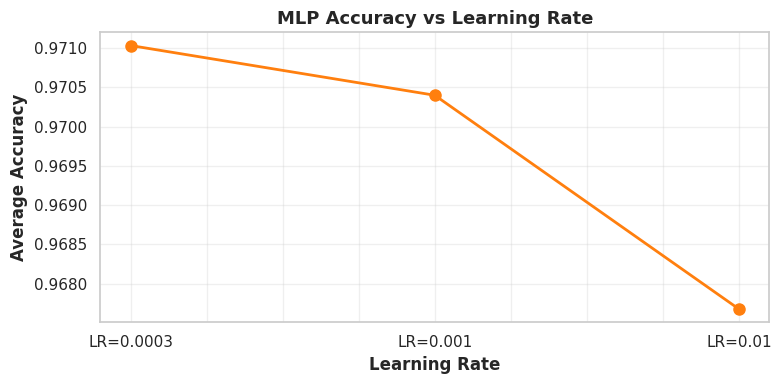

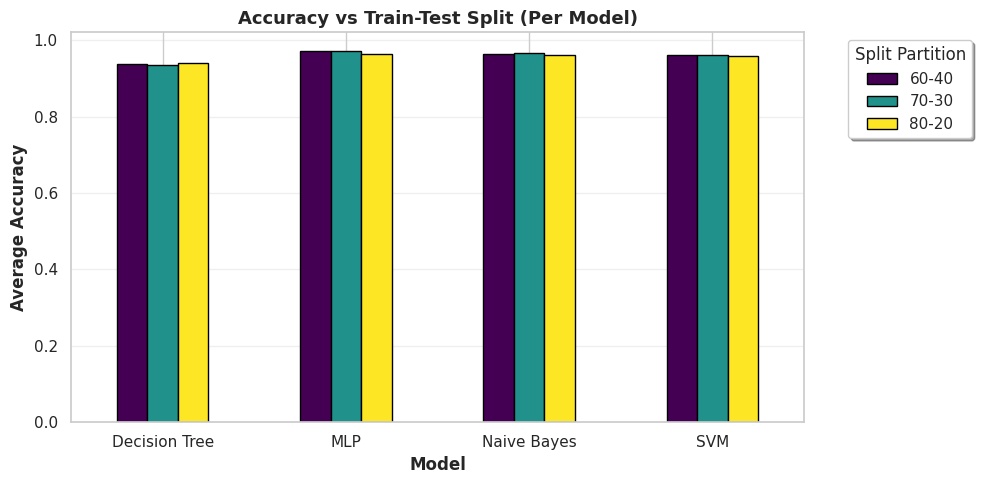

In [11]:
# ACCURACY BAR CHART
plt.figure(figsize=(8, 4))
model_avg = results_df.groupby('Model')['Accuracy'].mean().sort_values()
model_avg.plot(kind='barh', color='#1f77b4', edgecolor='black')
plt.title('Average Accuracy per Model', fontsize=13, fontweight='bold')
plt.xlabel('Accuracy', fontweight='bold')
plt.ylabel('Model', fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# LEARNING RATE LINE CHART
plt.figure(figsize=(8, 4))
mlp_data = results_df[results_df['Model'] == 'MLP']
lr_avg = mlp_data.groupby('Parameter / LR')['Accuracy'].mean()
lr_avg.plot(kind='line', marker='o', color='#ff7f0e', linewidth=2, markersize=8)
plt.title('MLP Accuracy vs Learning Rate', fontsize=13, fontweight='bold')
plt.xlabel('Learning Rate', fontweight='bold')
plt.ylabel('Average Accuracy', fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# TRAIN-TEST SPLIT BAR CHART
plt.figure(figsize=(10, 5))
split_avg = results_df.groupby(['Model', 'Split'])['Accuracy'].mean().unstack()
split_avg.plot(kind='bar', edgecolor='black', ax=plt.gca(), cmap='viridis')
plt.title('Accuracy vs Train-Test Split (Per Model)', fontsize=13, fontweight='bold')
plt.xlabel('Model', fontweight='bold')
plt.ylabel('Average Accuracy', fontweight='bold')
plt.legend(title='Split Partition', bbox_to_anchor=(1.05, 1), loc='upper left', shadow=True)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Proof that my model works:
(replace test_msg string with whatever you want to test)

In [12]:
def predict_new_message(message):
    cleaned = clean_text(message) #1 Clean message
    vectorized = tfidf.transform([cleaned]) #2 Vectorize using existing TF-IDF model
    dense_vec = vectorized.toarray()#3 Dense array for MLP
    prob = mlp_best.predict(dense_vec, verbose=0).flatten()[0]#4 Predict
    prediction = "Spam" if prob >= 0.5 else "Ham"
    return prediction, prob

test_msg = "Hey abdullah we have a quiz tomorrow in sb-002"#edit this
result, confidence = predict_new_message(test_msg)
print(f"Message: {test_msg}")
print(f"Prediction: {result}")

Message: Hey abdullah we have a quiz tomorrow in sb-002
Prediction: Ham
